<a href="https://colab.research.google.com/github/sanjaybat66-arch/Assignment-1/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


# Customer Segmentation using RFM Analysis

## Objective

### The objective of this project is to analyze customer purchasing behavior using RFM (Recency, Frequency, Monetary) Analysis. The customers will be segmented into different groups based on their purchasing patterns, helping businesses identify loyal customers, at-risk customers, and potential customers for targeted marketing strategies.

### **IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **LOAD DATASET**

In [ ]:

df = pd.read_excel('/content/Online Retail.xlsx', nrows=50000)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### **DATASET INFORMATION**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    50000 non-null  object        
 1   StockCode    50000 non-null  object        
 2   Description  49858 non-null  object        
 3   Quantity     50000 non-null  int64         
 4   InvoiceDate  50000 non-null  datetime64[ns]
 5   UnitPrice    50000 non-null  float64       
 6   CustomerID   32119 non-null  float64       
 7   Country      50000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 3.1+ MB


In [ ]:
df.describe

<bound method NDFrame.describe of       InvoiceNo StockCode                          Description  Quantity  \
0        536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1        536365     71053                  WHITE METAL LANTERN         6   
2        536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3        536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4        536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...         ...       ...                                  ...       ...   
49995    540541     21332         MOROCCAN BEATEN METAL MIRROR         1   
49996    540541     20831                     GOLD PHOTO FRAME         6   
49997    540541     22169     FAMILY ALBUM WHITE PICTURE FRAME         2   
49998    540541     22170   PICTURE FRAME WOOD TRIPLE PORTRAIT         4   
49999    540541     22415                    WHITE TISSUE REAM         1   

              InvoiceDate  UnitPrice  CustomerID         Country  
0     2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1     2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2     2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3     2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4     2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
...                   ...        ...         ...             ...  
49995 2011-01-09 15:13:00      12.75     15799.0  United Kingdom  
49996 2011-01-09 15:13:00       2.10     15799.0  United Kingdom  
49997 2011-01-09 15:13:00       8.50     15799.0  United Kingdom  
49998 2011-01-09 15:13:00       6.75     15799.0  United Kingdom  
49999 2011-01-09 15:13:00       7.95     15799.0  United Kingdom  

[50000 rows x 8 columns]>

### **DATA CLEANING**

In [ ]:
print(df.isnull().sum())

InvoiceNo          0
StockCode          0
Description      142
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     17881
Country            0
dtype: int64


In [ ]:
print(df.duplicated().sum())

537


In [ ]:
df = df.dropna(subset=['CustomerID'])

In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.shape)

(31586, 8)


### **CREATE MONETARY VALUE**

In [ ]:
df['MonetaryValue'] = df['Quantity'] * df['UnitPrice']

### **CONVERT INVOICE DATE**

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

### **CALCULATE RFM METRICS**

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'MonetaryValue': 'sum'
})

**RENAME COLUMNS**

In [ ]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

**VIEW RFM TABLE**

In [ ]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,34,1,711.79
12348.0,24,1,892.80
12370.0,24,2,1864.27
12377.0,21,1,1001.52
12383.0,19,1,600.72


**CHECK SHAPE**

In [ ]:
print(rfm.shape)

(1039, 3)


### **RFM SCORING**

In [ ]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

**TOTAL RFM SCORE**

In [ ]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

### **CUSTOMER SEGMENTATION**

In [ ]:
def segment_customer(score):
    if score >= 10:
        return 'High Value'
    elif score >= 7:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm['Customer_Segment'] = rfm['RFM_Score'].apply(segment_customer)

**CHECK SEGMENT COUNTS**

In [ ]:
rfm['Customer_Segment'].value_counts()

,count
Customer_Segment,
Low Value,389
Medium Value,388
High Value,262


## Customer Segment Distribution - Bar Chart

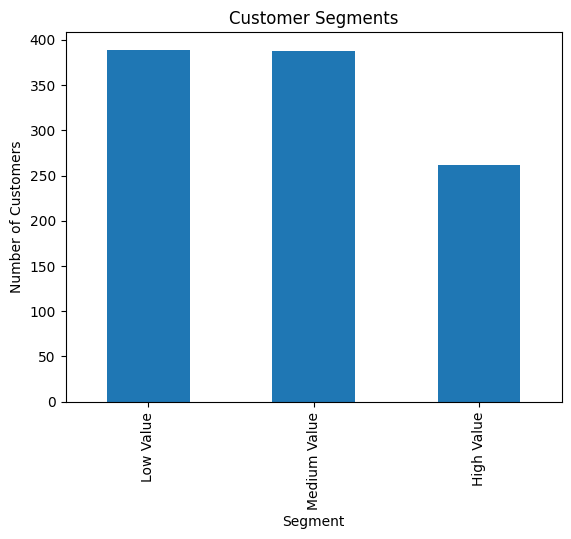

In [ ]:
rfm['Customer_Segment'].value_counts().plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()

## Customer Segment Distribution - Pie Chart

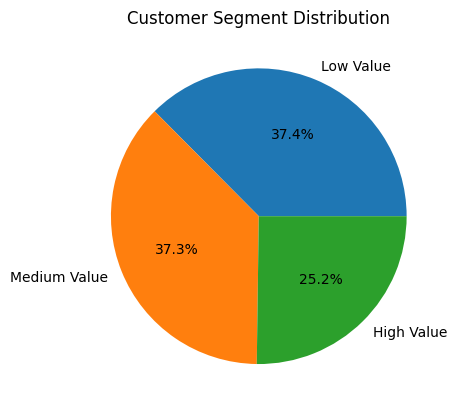

In [ ]:
rfm['Customer_Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Customer Segment Distribution')
plt.ylabel('')

plt.show()

### **Insights**

1. A total of 1039 customers were analyzed using RFM analysis.

2. Low Value customers formed the largest segment with 389 customers.

3. Medium Value customers accounted for 388 customers, indicating a significant number of customers with moderate purchasing behavior.

4. High Value customers accounted for 262 customers and represent the most valuable customer group.

5. High Value customers contribute significantly to business revenue and should be targeted for retention strategies.

6. Low Value customers can be targeted through promotional campaigns to increase engagement and purchase frequency.

 7. RFM analysis helps businesses understand customer behavior and design personalized marketing strategies.

## **Conclusion**

This project applied RFM (Recency, Frequency, Monetary) analysis to segment customers based on their purchasing behavior. Customers were categorized into High Value, Medium Value, and Low Value segments. The analysis revealed that most customers belong to the Low and Medium Value segments, while a smaller group of High Value customers contributes significant value to the business. RFM analysis provides valuable insights that can help organizations improve customer retention, marketing effectiveness, and overall business performance.